In [3]:
# ============================================================================
# Drought characterization — Sao Francisco basin
# Method: Run Theory (Yevjevich, 1967)
# Index: SSI-12
# Metrics: Frequency, Duration (median), Severity (median)
# Definition: event starts when SSI < -1 for >= 2 consecutive months
#             event ends when SSI >= 0
# Reference: Spinoni et al. (2014), Tabari et al. (2021)
# Scenarios: Historical (1985-2014), SSP126 (2041-2070), SSP585 (2041-2070)
# Models: MPI-ESM1-2-HR, UKESM1-0-LL, GFDL-ESM4, IPSL-CM6A-LR, MRI-ESM2-0
# ============================================================================

import os
import numpy as np
import xarray as xr
import netCDF4 as nc
from pathlib import Path

# --- CONFIGURATION ---
models    = ["MPI-ESM1-2-HR", "UKESM1-0-LL", "GFDL-ESM4", "IPSL-CM6A-LR", "MRI-ESM2-0"]
scenarios = ["historical", "ssp126", "ssp585"]
basin     = "sao_francisco"
SSI_VAR   = "SSI_12"

path_in  = "/data/brussel/vo/000/bvo00033/vsc11346/SSI_R/3.Outputs_SSI/2.baseline_105/Sao_Francisco/"
path_out = "/data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/"


# ============================================================================
# FUNCTION: Calculate drought metrics for a single time series
# ============================================================================
def calc_drought_metrics(ssi_ts):
    """
    Calculates drought frequency, duration and severity using run theory.

    Parameters:
        ssi_ts (np.array): SSI-12 time series for a single pixel

    Returns:
        frequency (int):         number of drought events
        duration_median (float): median duration across all events (months)
        severity_median (float): median severity across all events (sum of |SSI|)

    Event definition:
        Start: SSI < -1 for >= 2 consecutive months
        End:   SSI >= 0
    """
    n           = len(ssi_ts)
    in_event    = False
    consec_neg  = 0
    event_start = None
    durations   = []
    severities  = []

    for t in range(n):
        val = ssi_ts[t]

        if np.isnan(val):
            in_event   = False
            consec_neg = 0
            continue

        if not in_event:
            if val < -1:
                consec_neg += 1
                if consec_neg >= 2:
                    in_event    = True
                    event_start = t - 1
            else:
                consec_neg = 0
        else:
            if val >= 0:
                duration = (t - 1) - event_start + 1
                severity = np.sum(np.abs(ssi_ts[event_start:t]))
                durations.append(duration)
                severities.append(severity)
                in_event   = False
                consec_neg = 0

    # Handle event that does not close before end of series
    if in_event:
        duration = (n - 1) - event_start + 1
        severity = np.sum(np.abs(ssi_ts[event_start:n]))
        durations.append(duration)
        severities.append(severity)

    frequency = len(durations)

    if frequency == 0:
        return frequency, np.nan, np.nan

    return frequency, np.median(durations), np.median(severities)


# ============================================================================
# FUNCTION: Save drought metrics as NetCDF
# ============================================================================
def save_netcdf(freq_grid, dur_grid, sev_grid, lon, lat,
                basin, scenario, model, output_dir):
    """
    Saves drought metrics (frequency, duration, severity) into a single NetCDF.
    Arrays are stored in (lat, lon) order following CF conventions.
    """
    output_file = f"{output_dir}drought_metrics_{basin}_{scenario}_{model}.nc"
    ds_out      = nc.Dataset(output_file, "w", format="NETCDF4")

    ds_out.createDimension("lat", len(lat))
    ds_out.createDimension("lon", len(lon))

    lat_var       = ds_out.createVariable("lat", "f4", ("lat",))
    lat_var.units = "degrees_north"
    lat_var[:]    = lat

    lon_var       = ds_out.createVariable("lon", "f4", ("lon",))
    lon_var.units = "degrees_east"
    lon_var[:]    = lon

    freq_save = np.where(np.isnan(freq_grid), -9999, freq_grid)
    dur_save  = np.where(np.isnan(dur_grid),  -9999, dur_grid)
    sev_save  = np.where(np.isnan(sev_grid),  -9999, sev_grid)

    freq_var           = ds_out.createVariable("frequency", "f4", ("lat", "lon"),
                                                fill_value=-9999)
    freq_var.units     = "count"
    freq_var.long_name = "Number of drought events"
    freq_var[:]        = freq_save

    dur_var           = ds_out.createVariable("duration", "f4", ("lat", "lon"),
                                               fill_value=-9999)
    dur_var.units     = "months"
    dur_var.long_name = "Median drought duration"
    dur_var[:]        = dur_save

    sev_var           = ds_out.createVariable("severity", "f4", ("lat", "lon"),
                                               fill_value=-9999)
    sev_var.units     = "-"
    sev_var.long_name = "Median drought severity (sum of |SSI| per event)"
    sev_var[:]        = sev_save

    ds_out.description = (f"Drought characteristics — {basin} basin, "
                          f"{scenario}, {model}. "
                          f"Run theory (Yevjevich 1967): "
                          f"start SSI < -1 for >= 2 months, end SSI >= 0.")
    ds_out.index       = "SSI-12"
    ds_out.basin       = basin
    ds_out.scenario    = scenario
    ds_out.model       = model

    ds_out.close()
    print(f"    Saved: {output_file}")


# ============================================================================
# FUNCTION: Calculate ensemble median across 5 models
# ============================================================================
def calc_ensemble(basin, scenario, models, output_dir):
    """
    Reads individual model NetCDFs and calculates pixel-wise median
    across all models for each metric.
    """
    freq_stack = []
    dur_stack  = []
    sev_stack  = []

    for model in models:
        nc_file = f"{output_dir}drought_metrics_{basin}_{scenario}_{model}.nc"
        ds      = xr.open_dataset(nc_file)

        freq = ds["frequency"].values.astype(float)
        dur  = ds["duration"].values.astype(float)
        sev  = ds["severity"].values.astype(float)

        freq = np.where(freq == -9999, np.nan, freq)
        dur  = np.where(dur  == -9999, np.nan, dur)
        sev  = np.where(sev  == -9999, np.nan, sev)

        freq_stack.append(freq)
        dur_stack.append(dur)
        sev_stack.append(sev)

        lon = ds["lon"].values
        lat = ds["lat"].values
        ds.close()

    freq_ensemble = np.nanmedian(np.stack(freq_stack, axis=0), axis=0)
    dur_ensemble  = np.nanmedian(np.stack(dur_stack,  axis=0), axis=0)
    sev_ensemble  = np.nanmedian(np.stack(sev_stack,  axis=0), axis=0)

    save_netcdf(freq_ensemble, dur_ensemble, sev_ensemble,
                lon, lat, basin, scenario, "ensemble", output_dir)

    print(f"\n  Ensemble summary — {scenario}:")
    for name, grid in [("FREQUENCY", freq_ensemble),
                       ("DURATION",  dur_ensemble),
                       ("SEVERITY",  sev_ensemble)]:
        valid = grid[~np.isnan(grid)]
        print(f"    {name}: min={valid.min():.2f}, "
              f"max={valid.max():.2f}, "
              f"median={np.median(valid):.2f}")


# ============================================================================
# MAIN LOOP — SCENARIOS x MODELS
# ============================================================================
for scenario in scenarios:

    out_dir = f"{path_out}{scenario}/"
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"SCENARIO: {scenario.upper()} | BASIN: {basin.upper()}")
    print(f"{'='*60}")

    for model in models:

        print(f"\n  Processing: {model}")

        # Read SSI-12 NetCDF
        nc_file = f"{path_in}{scenario}/ssi12_{basin}_{scenario}_{model}.nc"
        ds      = xr.open_dataset(nc_file)
        ssi     = ds[SSI_VAR].values
        lon     = ds["lon"].values
        lat     = ds["lat"].values
        dims    = ds[SSI_VAR].dims
        ds.close()

        # Replace fill values
        ssi = np.where(ssi == -9999, np.nan, ssi)

        # Ensure (lat, lon, time) order — input comes as (time, lat, lon)
        if dims[0] == "time":
            ssi = np.transpose(ssi, (1, 2, 0))

        n_lat, n_lon, _ = ssi.shape

        # Initialize output grids — shape (n_lat, n_lon)
        freq_grid = np.full((n_lat, n_lon), np.nan)
        dur_grid  = np.full((n_lat, n_lon), np.nan)
        sev_grid  = np.full((n_lat, n_lon), np.nan)

        # Pixel-by-pixel calculation
        for i in range(n_lat):
            for j in range(n_lon):
                ts = ssi[i, j, :]
                if np.all(np.isnan(ts)):
                    continue
                (freq_grid[i, j],
                 dur_grid[i, j],
                 sev_grid[i, j]) = calc_drought_metrics(ts)

        # Print model summary
        for name, grid in [("FREQUENCY", freq_grid),
                           ("DURATION",  dur_grid),
                           ("SEVERITY",  sev_grid)]:
            valid = grid[~np.isnan(grid)]
            print(f"    {name}: min={valid.min():.2f}, "
                  f"max={valid.max():.2f}, "
                  f"median={np.median(valid):.2f}")

        # Save individual model NetCDF
        save_netcdf(freq_grid, dur_grid, sev_grid,
                    lon, lat, basin, scenario, model, out_dir)

    # Calculate and save ensemble median
    print(f"\n  Computing ensemble median — {scenario}")
    calc_ensemble(basin, scenario, models, out_dir)


print(f"\n{'='*60}")
print(f"COMPLETED — Sao Francisco basin, 5 models, 3 scenarios")
print(f"Output: {path_out}")
print(f"{'='*60}")


SCENARIO: HISTORICAL | BASIN: SAO_FRANCISCO

  Processing: MPI-ESM1-2-HR
    FREQUENCY: min=0.00, max=8.00, median=1.00
    DURATION: min=2.00, max=74.00, median=13.00
    SEVERITY: min=2.08, max=52.12, median=12.36
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/historical/drought_metrics_sao_francisco_historical_MPI-ESM1-2-HR.nc

  Processing: UKESM1-0-LL
    FREQUENCY: min=0.00, max=9.00, median=3.00
    DURATION: min=4.00, max=108.00, median=17.00
    SEVERITY: min=3.76, max=85.70, median=15.94
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/historical/drought_metrics_sao_francisco_historical_UKESM1-0-LL.nc

  Processing: GFDL-ESM4
    FREQUENCY: min=0.00, max=8.00, median=5.00
    DURATION: min=2.00, max=90.50, median=20.00
    SEVERITY: min=2.12, max=71.91, median=17.22
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/S

/tmp/ipykernel_2289767/2946692380.py:185: RuntimeWarning: All-NaN slice encountered
  freq_ensemble = np.nanmedian(np.stack(freq_stack, axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:186: RuntimeWarning: All-NaN slice encountered
  dur_ensemble  = np.nanmedian(np.stack(dur_stack,  axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:187: RuntimeWarning: All-NaN slice encountered
  sev_ensemble  = np.nanmedian(np.stack(sev_stack,  axis=0), axis=0)


    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/historical/drought_metrics_sao_francisco_historical_ensemble.nc

  Ensemble summary — historical:
    FREQUENCY: min=0.00, max=7.00, median=4.00
    DURATION: min=7.50, max=85.00, median=20.00
    SEVERITY: min=3.04, max=35.17, median=16.99

SCENARIO: SSP126 | BASIN: SAO_FRANCISCO

  Processing: MPI-ESM1-2-HR
    FREQUENCY: min=0.00, max=8.00, median=4.00
    DURATION: min=2.00, max=102.00, median=14.00
    SEVERITY: min=2.13, max=58.98, median=12.71
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/ssp126/drought_metrics_sao_francisco_ssp126_MPI-ESM1-2-HR.nc

  Processing: UKESM1-0-LL
    FREQUENCY: min=0.00, max=11.00, median=3.00
    DURATION: min=2.00, max=96.00, median=20.00
    SEVERITY: min=2.01, max=43.84, median=19.52
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Fr

/tmp/ipykernel_2289767/2946692380.py:185: RuntimeWarning: All-NaN slice encountered
  freq_ensemble = np.nanmedian(np.stack(freq_stack, axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:186: RuntimeWarning: All-NaN slice encountered
  dur_ensemble  = np.nanmedian(np.stack(dur_stack,  axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:187: RuntimeWarning: All-NaN slice encountered
  sev_ensemble  = np.nanmedian(np.stack(sev_stack,  axis=0), axis=0)


    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/ssp126/drought_metrics_sao_francisco_ssp126_ensemble.nc

  Ensemble summary — ssp126:
    FREQUENCY: min=0.00, max=8.00, median=4.00
    DURATION: min=3.00, max=53.75, median=17.50
    SEVERITY: min=2.37, max=34.84, median=16.23

SCENARIO: SSP585 | BASIN: SAO_FRANCISCO

  Processing: MPI-ESM1-2-HR
    FREQUENCY: min=0.00, max=10.00, median=2.00
    DURATION: min=2.00, max=93.00, median=18.00
    SEVERITY: min=2.26, max=53.54, median=14.55
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/ssp585/drought_metrics_sao_francisco_ssp585_MPI-ESM1-2-HR.nc

  Processing: UKESM1-0-LL
    FREQUENCY: min=0.00, max=9.00, median=2.00
    DURATION: min=2.00, max=56.50, median=14.00
    SEVERITY: min=2.04, max=45.86, median=13.26
    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/ssp58

/tmp/ipykernel_2289767/2946692380.py:185: RuntimeWarning: All-NaN slice encountered
  freq_ensemble = np.nanmedian(np.stack(freq_stack, axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:186: RuntimeWarning: All-NaN slice encountered
  dur_ensemble  = np.nanmedian(np.stack(dur_stack,  axis=0), axis=0)
/tmp/ipykernel_2289767/2946692380.py:187: RuntimeWarning: All-NaN slice encountered
  sev_ensemble  = np.nanmedian(np.stack(sev_stack,  axis=0), axis=0)


    Saved: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/ssp585/drought_metrics_sao_francisco_ssp585_ensemble.nc

  Ensemble summary — ssp585:
    FREQUENCY: min=0.00, max=7.00, median=3.00
    DURATION: min=5.00, max=49.00, median=14.00
    SEVERITY: min=3.68, max=27.06, median=13.85

COMPLETED — Sao Francisco basin, 5 models, 3 scenarios
Output: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/


CONTEO DE PÍXELES VÁLIDOS (no-NaN) — ENSEMBLE

  HISTORICAL
    frequency : 3146/37576 píxeles válidos (8.4%)
    duration  : 3121/37576 píxeles válidos (8.3%)
    severity  : 3121/37576 píxeles válidos (8.3%)

  SSP126
    frequency : 3146/37576 píxeles válidos (8.4%)
    duration  : 3137/37576 píxeles válidos (8.3%)
    severity  : 3137/37576 píxeles válidos (8.3%)

  SSP585
    frequency : 3146/37576 píxeles válidos (8.4%)
    duration  : 3084/37576 píxeles válidos (8.2%)
    severity  : 3084/37576 píxeles válidos (8.2%)

CONSISTENCIA DE MÁSCARA ENTRE ESCENARIOS
  historical vs ssp126: OK, mismas máscaras (3146 píxeles)
  historical vs ssp585: OK, mismas máscaras (3146 píxeles)

  Figura guardada: /data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/verification_maps_sao_francisco.png


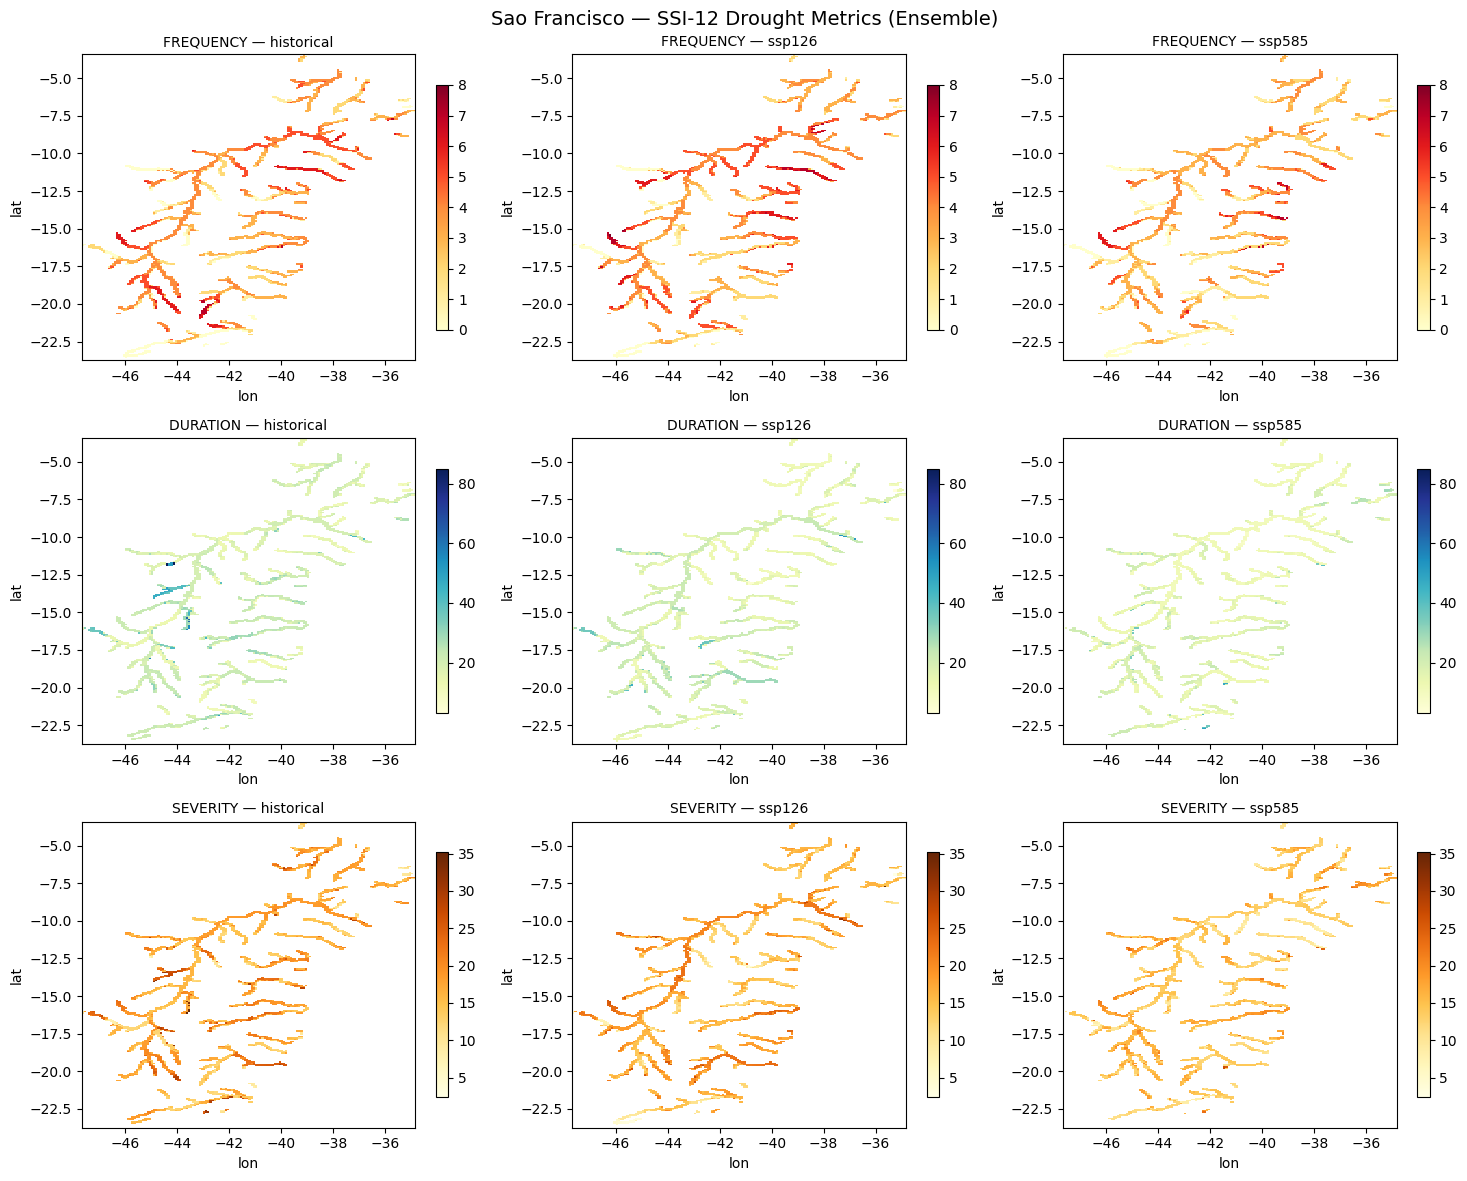


CHEQUEO DE ORIENTACIÓN ESPACIAL
  lat: -23.71 a -3.46 (creciente)
  lon: -47.62 a -34.88 (creciente)
  Shape de frequency: (244, 154) (debería ser lat=244, lon=154)

VERIFICACIÓN COMPLETADA


In [4]:
# ============================================================================
# VERIFICATION — Sao Francisco: mapas espaciales + conteo de píxeles válidos
# ============================================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

basin     = "sao_francisco"
scenarios = ["historical", "ssp126", "ssp585"]
path_out  = "/data/brussel/vo/000/bvo00033/vsc11346/SSI_R/5.Caracterizacion/2.Evento/2.Outputs/Sao_Francisco/"

metrics = ["frequency", "duration", "severity"]


# ----------------------------------------------------------------------------
# PARTE 1 — Conteo de píxeles válidos por escenario (ensemble)
# ----------------------------------------------------------------------------
print("="*70)
print("CONTEO DE PÍXELES VÁLIDOS (no-NaN) — ENSEMBLE")
print("="*70)

data_ensemble = {}

for scenario in scenarios:
    nc_file = f"{path_out}{scenario}/drought_metrics_{basin}_{scenario}_ensemble.nc"
    ds      = xr.open_dataset(nc_file)

    print(f"\n  {scenario.upper()}")
    for metric in metrics:
        arr   = ds[metric].values
        arr   = np.where(arr == -9999, np.nan, arr)
        valid = np.sum(~np.isnan(arr))
        total = arr.size
        print(f"    {metric:10s}: {valid}/{total} píxeles válidos "
              f"({100*valid/total:.1f}%)")

    data_ensemble[scenario] = ds
    # No cerramos ds todavía porque lo usamos para graficar abajo


# ----------------------------------------------------------------------------
# PARTE 2 — Comparación de píxeles válidos entre escenarios (misma máscara?)
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("CONSISTENCIA DE MÁSCARA ENTRE ESCENARIOS")
print(f"{'='*70}")

masks = {}
for scenario in scenarios:
    arr = data_ensemble[scenario]["frequency"].values
    arr = np.where(arr == -9999, np.nan, arr)
    masks[scenario] = ~np.isnan(arr)

# Comparar historical vs ssp126 vs ssp585
ref_mask = masks["historical"]
for scenario in scenarios[1:]:
    diff = np.sum(ref_mask != masks[scenario])
    if diff == 0:
        print(f"  historical vs {scenario}: OK, mismas máscaras ({np.sum(ref_mask)} píxeles)")
    else:
        print(f"  ⚠️  historical vs {scenario}: {diff} píxeles con máscara distinta "
              f"— revisar si el dominio/land-mask cambió entre escenarios")


# ----------------------------------------------------------------------------
# PARTE 3 — Mapas espaciales (3 escenarios x 3 métricas = 9 subplots)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(len(metrics), len(scenarios), figsize=(15, 12))

cmap_dict = {
    "frequency": "YlOrRd",
    "duration":  "YlGnBu",
    "severity":  "YlOrBr",
}

for row, metric in enumerate(metrics):

    # Escala de color común entre los 3 escenarios para poder comparar
    vmin, vmax = np.inf, -np.inf
    for scenario in scenarios:
        arr = data_ensemble[scenario][metric].values
        arr = np.where(arr == -9999, np.nan, arr)
        if np.all(np.isnan(arr)):
            continue
        vmin = min(vmin, np.nanmin(arr))
        vmax = max(vmax, np.nanmax(arr))

    for col, scenario in enumerate(scenarios):
        ax  = axes[row, col]
        ds  = data_ensemble[scenario]
        arr = ds[metric].values
        arr = np.where(arr == -9999, np.nan, arr)
        lon = ds["lon"].values
        lat = ds["lat"].values

        im = ax.pcolormesh(lon, lat, arr, cmap=cmap_dict[metric],
                           vmin=vmin, vmax=vmax, shading="auto")
        ax.set_title(f"{metric.upper()} — {scenario}", fontsize=10)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Sao Francisco — SSI-12 Drought Metrics (Ensemble)", fontsize=14)
plt.tight_layout()

fig_out = f"{path_out}verification_maps_{basin}.png"
plt.savefig(fig_out, dpi=150, bbox_inches="tight")
print(f"\n  Figura guardada: {fig_out}")
plt.show()


# ----------------------------------------------------------------------------
# PARTE 4 — Chequeo rápido de orientación espacial
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("CHEQUEO DE ORIENTACIÓN ESPACIAL")
print(f"{'='*70}")

ds_hist = data_ensemble["historical"]
lat_vals = ds_hist["lat"].values
lon_vals = ds_hist["lon"].values

print(f"  lat: {lat_vals.min():.2f} a {lat_vals.max():.2f} "
      f"({'creciente' if lat_vals[0] < lat_vals[-1] else 'decreciente'})")
print(f"  lon: {lon_vals.min():.2f} a {lon_vals.max():.2f} "
      f"({'creciente' if lon_vals[0] < lon_vals[-1] else 'decreciente'})")
print(f"  Shape de frequency: {ds_hist['frequency'].values.shape} "
      f"(debería ser lat={len(lat_vals)}, lon={len(lon_vals)})")

# Cerrar todos los datasets
for scenario in scenarios:
    data_ensemble[scenario].close()

print(f"\n{'='*70}")
print("VERIFICACIÓN COMPLETADA")
print(f"{'='*70}")